# **Metanálise**

---



In [16]:
import pandas as pd
import numpy as np
from scipy.stats import norm

In [17]:
# Carregar a planilha com os dados 
df = pd.read_csv('meta-analysis.csv', sep=',')

## Tamanho do Efeito

---

In [18]:
df

,Estudo,Amostras,Acurácia_Antes_da_Intervenção,Acurácia_01 %,Acurácia_02 %,Desvio_Padrão,Redução %
0,Estudo 1,10288,81.00,95.00,98.26,NaN,-21.30
1,Estudo 2,1.300.000,90.41,NaN,96.00,NaN,-6.21
2,Estudo 3,10616,96.35,NaN,96.91,NaN,"-0,58"
3,Estudo 4,1.030.000,99.03,99.90,99.99,NaN,-0.96
4,Estudo 5,668,83.50,96.70,96.71,NaN,-15.82
5,Estudo 6,512,NaN,90.00,95.00,NaN,NaN
6,Estudo 7,60000,NaN,85.00,97.00,NaN,NaN
7,Estudo 8,668,92.00,95.00,99.00,NaN,-7.60
8,Estudo 9,656,90.00,98.97,98.00,NaN,-8.8
9,Estudo 10,6788,NaN,72.42,81.71,NaN,NaN


In [19]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# Lista para armazenar os resultados
resultados = []

# Valor crítico para IC de 95%
z = norm.ppf(0.975)

def calcular_tamanho_efeito(row):
    if pd.isna(row['Acurácia_Antes_da_Intervenção']):
        return []  # Retorna uma lista vazia se X1 não estiver presente

    X1 = row['Acurácia_Antes_da_Intervenção'] / 100  # Convertendo para proporção
    X3 = row['Acurácia_02 %'] / 100 if not pd.isna(row['Acurácia_02 %']) else None

    if X3 is None:
        return []  # Retorna uma lista vazia se X3 não estiver presente

    N = int(row['Amostras'].replace('.', ''))  # Removendo pontos e convertendo para inteiro

    # Calcular o desvio padrão das diferenças
    media = (X1 + X3) / 2
    #s_combinado = np.sqrt(((X1 - media)**2 + (X3 - media)**2) / 1)  # Desvio padrão das diferenças entre as duas acurácias
    s_combinado = np.sqrt((X1**2 + X3**2) / 2)
    # Calcular o tamanho do efeito
    d = (X3 - X1) / s_combinado  # Cohen's d
    g = d * (1 - (3 / (4*N - 9))) if N < 20 else d  # Hedges' g se necessário
    SE = 1 / np.sqrt(N)  # Erro padrão
    IC_inf = g - z * SE
    IC_sup = g + z * SE

    return [{'Estudo': row['Estudo'], 'Comparação': f'{X1*100:.2f}% vs {X3*100:.2f}%',
             'Cohen_d': round(d, 3), 'Hedges_g': round(g, 3),
             'Erro Padrão': round(SE, 3), 'IC_95%': f'[{IC_inf:.3f}, {IC_sup:.3f}]'}]

# Aplicar a função a cada linha
df_resultados = []
for _, row in df.iterrows():
    df_resultados.extend(calcular_tamanho_efeito(row))

df_resultados = pd.DataFrame(df_resultados)

# Salvar os resultados em um arquivo Excel
df_resultados.to_excel('tamanho_efeito_resultados.xlsx', index=False)

# Exibir os primeiros resultados
df_resultados


,Estudo,Comparação,Cohen_d,Hedges_g,Erro Padrão,IC_95%
0,Estudo 1,81.00% vs 98.26%,0.192,0.192,0.010,"[0.172, 0.211]"
1,Estudo 2,90.41% vs 96.00%,0.060,0.060,0.001,"[0.058, 0.062]"
2,Estudo 3,96.35% vs 96.91%,0.006,0.006,0.010,"[-0.013, 0.025]"
3,Estudo 4,99.03% vs 99.99%,0.010,0.010,0.001,"[0.008, 0.012]"
4,Estudo 5,83.50% vs 96.71%,0.146,0.146,0.039,"[0.070, 0.222]"
5,Estudo 8,92.00% vs 99.00%,0.073,0.073,0.039,"[-0.003, 0.149]"
6,Estudo 9,90.00% vs 98.00%,0.085,0.085,0.039,"[0.009, 0.162]"
7,Estudo 11,86.34% vs 84.92%,-0.017,-0.017,0.023,"[-0.061, 0.028]"
8,Estudo 12,71.27% vs 84.87%,0.174,0.174,0.016,"[0.143, 0.204]"
9,Estudo 13,80.00% vs 99.58%,0.217,0.217,0.013,"[0.191, 0.242]"


## Heterogeneidade

In [2]:
import pandas as pd

# Carregar a planilha com os dados usando a codificação 'latin1'
df2 = pd.read_csv('meta-analysis-02.csv', sep=';', encoding='utf-8')



## Estatística Q de Cochran -  Índice I² - p-valor - Teste de Egger

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import chi2, t

# Supondo que df2 já está carregado com as colunas mencionadas
# Remover linhas com valores nulos para garantir cálculos precisos
df_clean = df2.dropna(subset=["Cohen_d", "Erro Padrão"])

# Calcular o peso de cada estudo
df_clean['Peso'] = 1 / (df_clean['Erro Padrão'] ** 2)

# Calcular o efeito médio ponderado
mean_effect = np.sum(df_clean['Peso'] * df_clean['Cohen_d']) / np.sum(df_clean['Peso'])

# Calcular a Estatística Q de Cochran
df_clean['Q'] = df_clean['Peso'] * (df_clean['Cohen_d'] - mean_effect) ** 2
Q = np.sum(df_clean['Q'])

# Calcular o Índice I²
k = len(df_clean)
df_degrees = k - 1
I2 = max(0, (Q - df_degrees) / Q) * 100

# Calcular o p-valor para heterogeneidade
p_value = 1 - chi2.cdf(Q, df_degrees)

# Exibir os resultados
print(f"Estatística Q de Cochran: {Q:.2f}")
print(f"Índice I²: {I2:.2f}%")
print(f"p-valor: {p_value:.5f}")

# Interpretando os resultados:
# - Se I² for próximo de 0%, indica pouca heterogeneidade.
# - Se I² for alto (> 50%), há forte evidência de heterogeneidade.
# - Se o p-valor for pequeno (< 0.05), a heterogeneidade é estatisticamente significativa.

# Aplicar o teste de Egger para avaliar o viés de publicação
# Calcular os valores padronizados (Z) e a precisão (1/Erro Padrão)
df_clean['Z'] = df_clean['Cohen_d'] / df_clean['Erro Padrão']
df_clean['Precisao'] = 1 / df_clean['Erro Padrão']

# Regressão linear de Z em função da Precisão
X = np.vstack([np.ones(len(df_clean)), df_clean['Precisao']]).T
beta, _, _, _ = np.linalg.lstsq(X, df_clean['Z'], rcond=None)

# O intercepto beta[0] é o parâmetro que indica a presença de viés de publicação
t_stat = beta[0] / (np.std(df_clean['Z'] - X @ beta) / np.sqrt(len(df_clean)))

# Calcular o p-valor para o teste de Egger
p_valor_egger = 2 * (1 - t.cdf(np.abs(t_stat), df_degrees))

# Exibir os resultados do teste de Egger
print(f"Teste de Egger - Intercepto: {beta[0]:.2f}")
print(f"Teste de Egger - p-valor: {p_valor_egger:.5f}")

# Interpretando os resultados do teste de Egger:
# - Se o p-valor for pequeno (< 0.05), sugere a presença de viés de publicação.

Estatística Q de Cochran: 1799.82
Índice I²: 99.17%
p-valor: 0.00000
Teste de Egger - Intercepto: 3.13
Teste de Egger - p-valor: 0.24013


# ***Gráficos***


## Forest Plot

In [26]:
import pandas as pd
import numpy as np
from scipy.stats import chi2

# Valores de Cohen's d fornecidos
cohen_d_values = [0.192, 0.06, 0.006, 0.01, 0.146, 0.073, 0.085, -0.017, 0.174, 0.217, 0.077, 0.043, 0.182, 0.096, 0.02, -0.009]

# Converter para um DataFrame
df_cohen_d = pd.DataFrame(cohen_d_values, columns=['Cohen_d'])

# Dividir em subgrupos
subgroup1 = df_cohen_d[df_cohen_d['Cohen_d'] <= 0.10]
subgroup2 = df_cohen_d[df_cohen_d['Cohen_d'] > 0.10]

# Função para calcular heterogeneidade
def calculate_heterogeneity(df):
    df_clean = df.dropna(subset=["Cohen_d"])
    df_clean['Peso'] = 1 / (df_clean['Cohen_d'] ** 2)
    mean_effect = np.sum(df_clean['Peso'] * df_clean['Cohen_d']) / np.sum(df_clean['Peso'])
    df_clean['Q'] = df_clean['Peso'] * (df_clean['Cohen_d'] - mean_effect) ** 2
    Q = np.sum(df_clean['Q'])
    k = len(df_clean)
    df_degrees = k - 1
    I2 = max(0, (Q - df_degrees) / Q) * 100
    p_value = 1 - chi2.cdf(Q, df_degrees)
    return Q, I2, p_value

# Calcular heterogeneidade para cada subgrupo
Q1, I2_1, p_value1 = calculate_heterogeneity(subgroup1)
Q2, I2_2, p_value2 = calculate_heterogeneity(subgroup2)

# Exibir os resultados
print("Subgrupo 1 (Cohen's d <= 0.10):")
print(f"Estatística Q de Cochran: {Q1:.2f}")
print(f"Índice I²: {I2_1:.2f}%")
print(f"p-valor: {p_value1:.5f}")

print("\nSubgrupo 2 (Cohen's d > 0.10):")
print(f"Estatística Q de Cochran: {Q2:.2f}")
print(f"Índice I²: {I2_2:.2f}%")
print(f"p-valor: {p_value2:.5f}")

Subgrupo 1 (Cohen's d <= 0.10):
Estatística Q de Cochran: 10.04
Índice I²: 0.35%
p-valor: 0.43739

Subgrupo 2 (Cohen's d > 0.10):
Estatística Q de Cochran: 0.09
Índice I²: 0.00%
p-valor: 0.99910


Subgrupo 1 (Cohen's d <= 0.10):
Estatística Q de Cochran: 1274.32
Índice I²: 99.22%
p-valor: 0.00000

Subgrupo 2 (Cohen's d > 0.10):
Estatística Q de Cochran: 6.27
Índice I²: 36.25%
p-valor: 0.17957


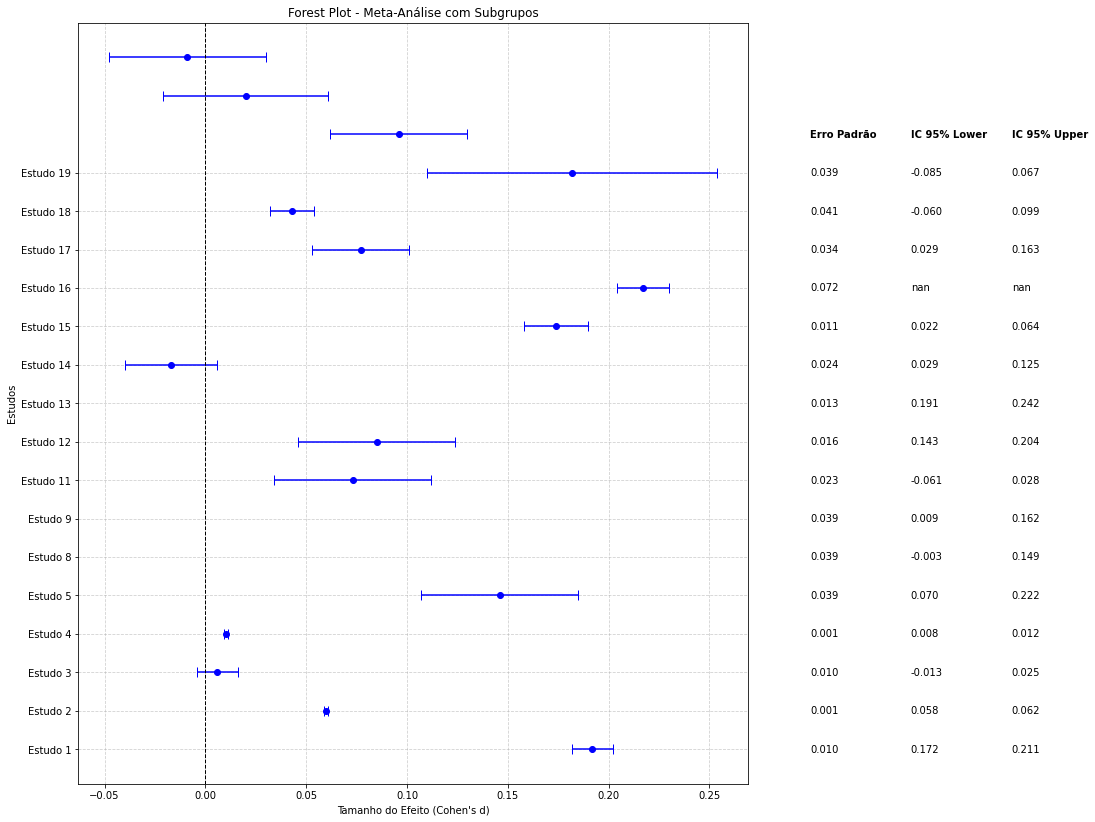

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Suponha que df2 já esteja carregado com os dados
# Remove estudos com NaN
df2 = df2.dropna(subset=['Cohen_d', 'Erro Padrão', 'IC_95%'])

# Limpando a coluna IC_95% para extrair os valores corretamente
df2[['IC_95%_Lower', 'IC_95%_Upper']] = df2['IC_95%'].str.extract(r'\[(.*) - (.*)\]').astype(float)

# Dividir em subgrupos
subgroup1 = df2[df2['Cohen_d'] <= 0.10]
subgroup2 = df2[df2['Cohen_d'] > 0.10]

# Função para calcular heterogeneidade
def calculate_heterogeneity(df):
    df_clean = df.dropna(subset=["Cohen_d", "Erro Padrão"])
    df_clean['Peso'] = 1 / (df_clean['Erro Padrão'] ** 2)
    mean_effect = np.sum(df_clean['Peso'] * df_clean['Cohen_d']) / np.sum(df_clean['Peso'])
    df_clean['Q'] = df_clean['Peso'] * (df_clean['Cohen_d'] - mean_effect) ** 2
    Q = np.sum(df_clean['Q'])
    k = len(df_clean)
    df_degrees = k - 1
    I2 = max(0, (Q - df_degrees) / Q) * 100
    p_value = 1 - chi2.cdf(Q, df_degrees)
    return Q, I2, p_value

# Calcular heterogeneidade para cada subgrupo
Q1, I2_1, p_value1 = calculate_heterogeneity(subgroup1)
Q2, I2_2, p_value2 = calculate_heterogeneity(subgroup2)

# Exibir os resultados
print("Subgrupo 1 (Cohen's d <= 0.10):")
print(f"Estatística Q de Cochran: {Q1:.2f}")
print(f"Índice I²: {I2_1:.2f}%")
print(f"p-valor: {p_value1:.5f}")

print("\nSubgrupo 2 (Cohen's d > 0.10):")
print(f"Estatística Q de Cochran: {Q2:.2f}")
print(f"Índice I²: {I2_2:.2f}%")
print(f"p-valor: {p_value2:.5f}")

# Criando o Forest Plot
plt.figure(figsize=(12, 14))

# Adicionando as anotações e cabeçalhos
annotations = []
for i, row in df2.iterrows():
    plt.errorbar(row['Cohen_d'], i, xerr=row['Erro Padrão'], fmt='o', color='b', capsize=5)
    annotations.append([row['Erro Padrão'], row['IC_95%_Lower'], row['IC_95%_Upper']])

# Adicionando uma linha central (efeito médio)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Configuração do gráfico
plt.yticks(range(len(df2)), df2['Estudo'])  # Nome dos estudos no eixo Y
plt.xlabel("Tamanho do Efeito (Cohen's d)")
plt.ylabel("Estudos")
plt.title("Forest Plot - Meta-Análise com Subgrupos")

# Adicionando as legendas
for i, (erro_padrao, ic_lower, ic_upper) in enumerate(annotations):
    plt.text(0.30, i, f"{erro_padrao:.3f}", va='center')
    plt.text(0.35, i, f"{ic_lower:.3f}", va='center')
    plt.text(0.40, i, f"{ic_upper:.3f}", va='center')

# Adicionando cabeçalhos das legendas
plt.text(0.30, len(df2), "Erro Padrão", va='center', fontweight='bold')
plt.text(0.35, len(df2), "IC 95% Lower", va='center', fontweight='bold')
plt.text(0.40, len(df2), "IC 95% Upper", va='center', fontweight='bold')

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Funel Plot

In [9]:
print(df2_clean[['Cohen_d', 'Erro Padrão']])


    Cohen_d  Erro Padrão
0     0.192        0.010
1     0.060        0.001
2     0.006        0.010
3     0.010        0.001
4     0.146        0.039
7     0.073        0.039
8     0.085        0.039
10   -0.017        0.023
11    0.174        0.016
12    0.217        0.013
13    0.077        0.024
14    0.043        0.011
15    0.182        0.072
16    0.096        0.034
17    0.020        0.041
18   -0.009        0.039


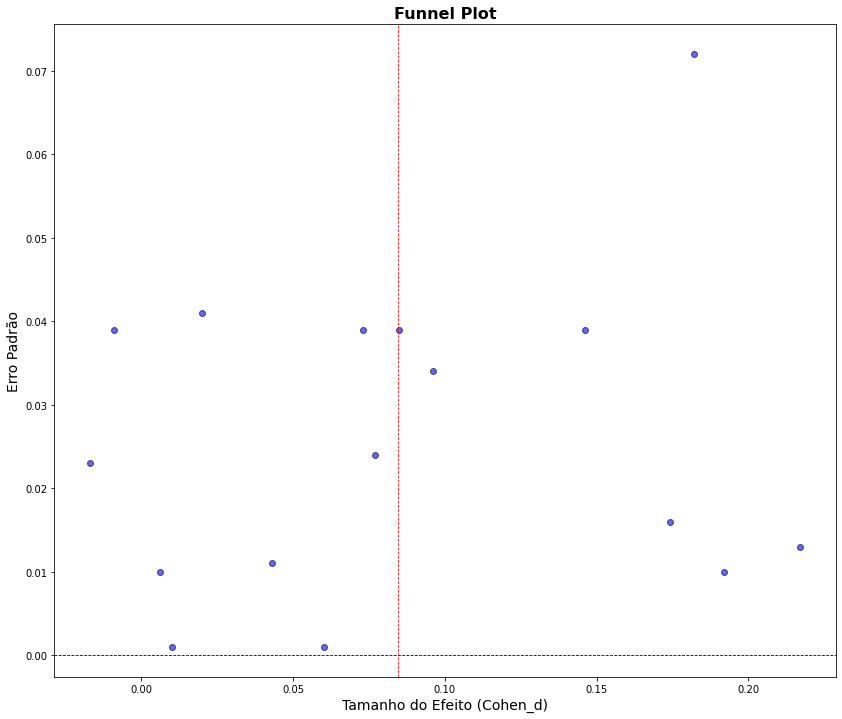

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Filtrando apenas os estudos que têm dados válidos para Cohen_d e Erro Padrão
df2_clean = df2[['Cohen_d', 'Erro Padrão']].dropna()

# Extraindo os valores necessários
effect_size = df2_clean['Cohen_d']  # Tamanho do efeito
std_error = df2_clean['Erro Padrão']  # Erro padrão

# Criando o Funnel Plot
plt.figure(figsize=(14, 12))
plt.scatter(effect_size, std_error, c='b', alpha=0.6, edgecolors='k')

# Adicionando as linhas de referência
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(x=np.mean(effect_size), color='red', linewidth=0.8, linestyle='--')

# Invertendo o eixo Y para que erros menores fiquem no topo
#plt.gca().invert_yaxis()

# Configurações do gráfico
plt.title('Funnel Plot', fontsize=16, fontweight='bold')
#plt.suptitle('Visualização do Viés de Publicação e Heterogeneidade', fontsize=12, y=0.92)
plt.xlabel('Tamanho do Efeito (Cohen_d)', fontsize=14)
plt.ylabel('Erro Padrão', fontsize=14)

# Exibir o gráfico
plt.show()


## Funel Plot 

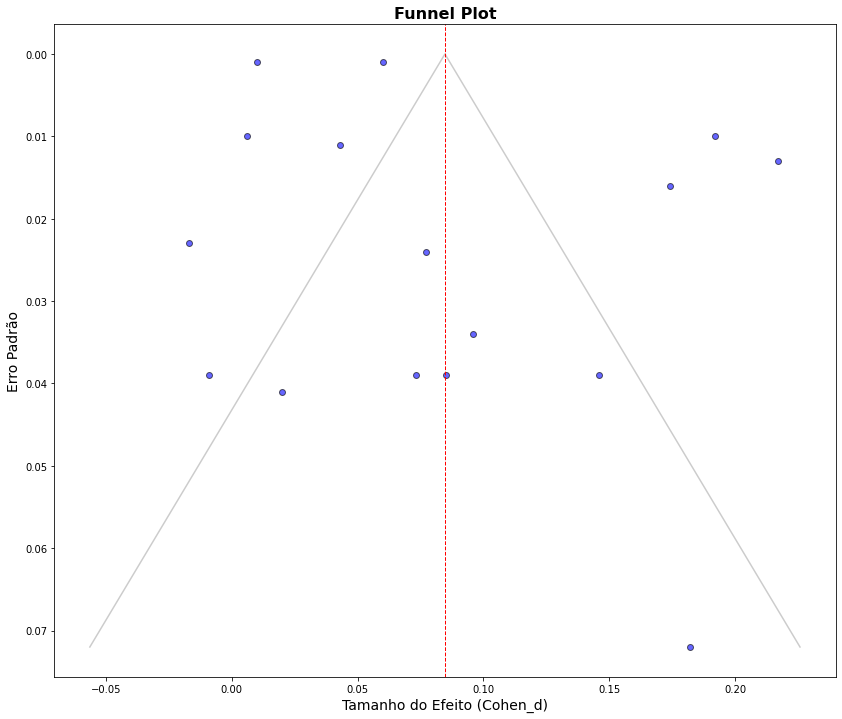

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definição das colunas necessárias
effect_size = df2['Cohen_d']  # Tamanho do efeito
std_error = df2['Erro Padrão']  # Erro padrão

# Calculando a média do tamanho do efeito
mean_effect = np.mean(effect_size)

# Configurações do gráfico
plt.figure(figsize=(14, 12))

# Plotando os pontos dos estudos
plt.scatter(effect_size, std_error, c='b', alpha=0.6, edgecolors='k')

# Definindo a altura máxima (erro padrão máximo)
max_se = max(std_error)

# Definindo os limites do funil (IC 95%)
x_left = mean_effect - 1.96 * max_se
x_right = mean_effect + 1.96 * max_se

# Desenhando o triângulo do funil
plt.plot([x_left, mean_effect, x_right], [max_se, 0, max_se], color='gray', alpha=0.4)

# Adicionando a linha de referência da média do tamanho do efeito
plt.axvline(mean_effect, color='red', linestyle='--', linewidth=1)

# Invertendo o eixo Y para que erros menores fiquem no topo
plt.gca().invert_yaxis()

# Configurações do gráfico
plt.title('Funnel Plot', fontsize=16, fontweight='bold')
#plt.suptitle('Visualização do Viés de Publicação e Heterogeneidade', fontsize=12, y=0.92)
plt.xlabel('Tamanho do Efeito (Cohen_d)', fontsize=14)
plt.ylabel('Erro Padrão', fontsize=14)

# Exibindo o gráfico
plt.show()
